# TCCT S82A — Blind-Counterfactual Failure Mechanism Audit

这是只读机制审计：锁定 S82 的有效盲测失败，不修改模型、策略、规范化器或干预。仅比较 8 个事实 Continue、8 个全局 Stop、8 个局部混合 Stop。

审计逐拒绝节点记录 raw radius-2/radius-3 hash、编码 token、节点角色和 frozen-policy hit，用于区分原始状态歧义、查询局部编码别名、非查询 token 泄漏和最终 OR 聚合问题。


Dataset[{<|Stage -> S82A, Name -> BlindCounterfactualFailureMechanismAudit, 
 
>     AuditOnly -> True, PriorS82ProtocolHash -> 
 
>      7695bea7ea07f903615ce01ad6b6a8481d2741ef1ce08fafb0e2d279e39f09bd, 
 
>     PriorS82BlindResultHash -> 
 
>      64be56fb8ef29638666efaf92cdcd03994a43e3328236fd0f7bd73a4808aa58f, 
 
>     RuntimeMinimalKernelHash -> 
 
>      ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34, 
 
>     LegacyCheckpointMinimalKernelHash -> 
 
>      ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34, 
 
>     MinimalKernelDefinitionTextHash -> 
 
>      d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922, 
 
>     RuntimeFrozenArchitectureHash -> 
 
>      47c0f2de12d2b8d1d0311f7a0fecacba782ff9f0b391b3c86631fdb569a8a3b7, 
 
>     LegacyCheckpointFrozenArchitectureHash -> 
 
>      47c0f2de12d2b8d1d0311f7a0fecacba782ff9f0b391b3c86631fdb569a8a3b7, 
 
>     StableFrozenArchitectureHash -> 
 
>      d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d, 
 
>     InterventionImplementationHash -> 
 
>      45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf, 
 
>     HistoricalRegressionRerun -> False, PolicyEditApplied -> False, 
 
>     RetuningApplied -> False, CandidateSearchRun -> False, NewModelSelected -> False, 
 
>     PreflightPassed -> True|>}, TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[
 
>      String], TypeSystem`AnyType, 18], 1], <||>]
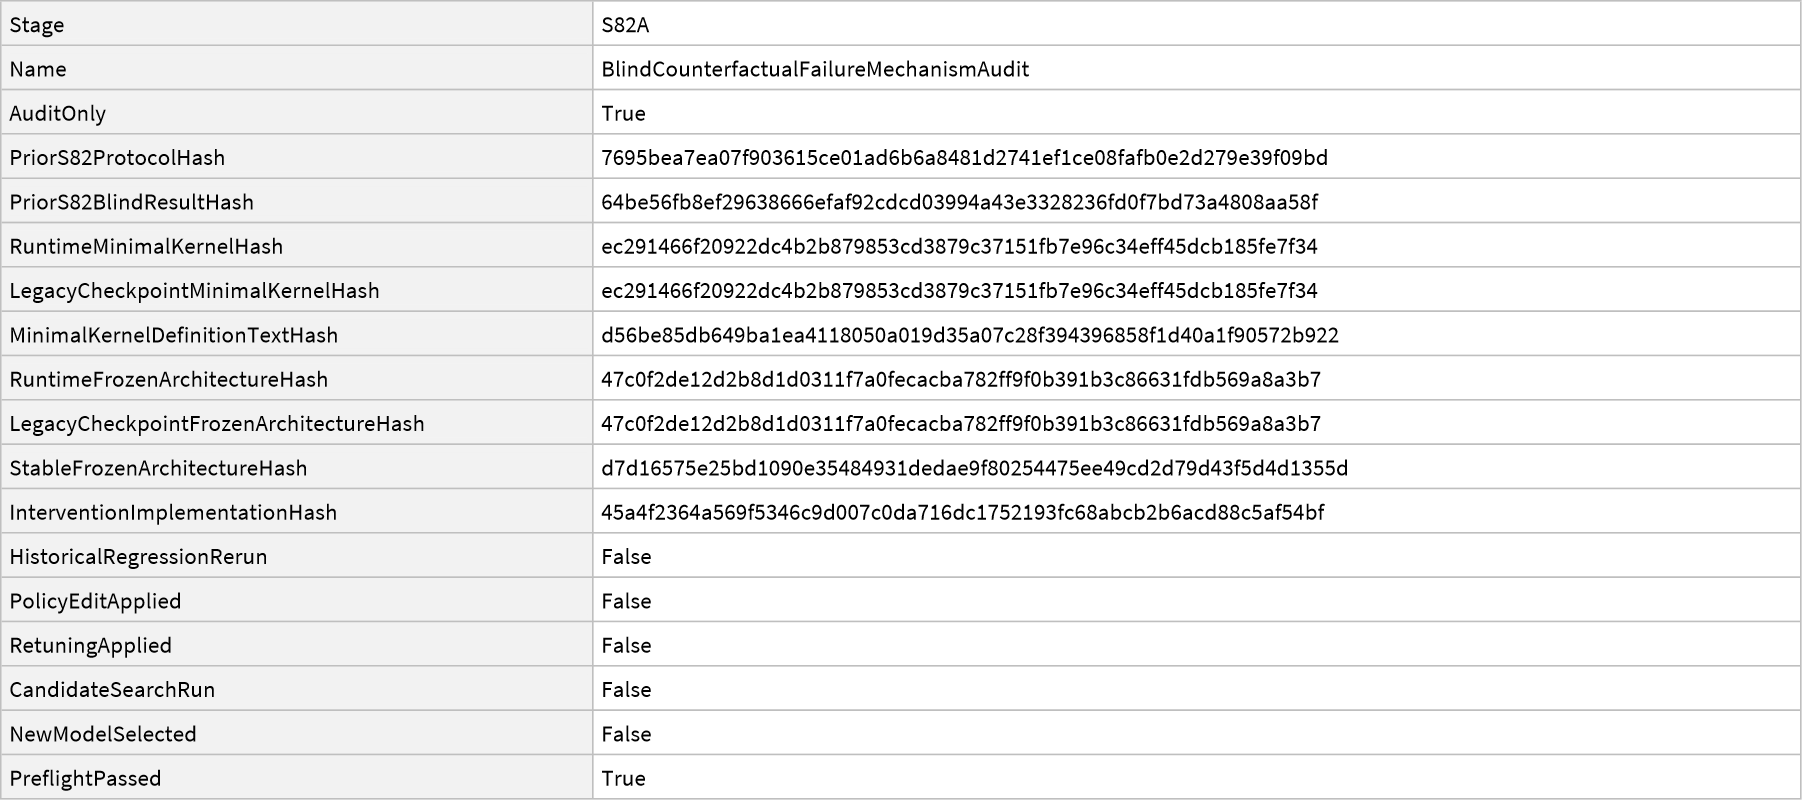

In [5]:





ClearAll["Global`*"];
$HistoryLength=0;

expectedFrozenModelHash79A=
"d6477c370436d09cf3e8cfc8530decd13ebf8bb79120362146ecb419f9d6a6c4";
expectedTopologySpecHash79A=
"b108aa7f2c59c395056fb9124e7d5d9074e39e5e124d0d98011800433e0dd95b";
expectedTopologyImplementationHash79A=
"f27d1ce683317d35a5e9da01536d95c706065810c27462e336cdb76f4a2dab52";
expectedS79BlindResultHash79A=
"b1ebf089e43121a61d4181139d4ba0a8970dc646a7a41425f861cff2e1f8461d";

frozen75D=<|
"Stage"->"S75D",
"Name"->"ValidatedPolicyCompletion",
"Representation"->
"PairedRadius2Radius3WithParentChildCardinality",
"Params"->{-1,0,-1,-1,-1,0,1,-1},
"K"->5,
"TrainingPolicy"->{{3,1},{3,3},{4,3}},
"Policy"->{
{1,3},{2,2},{3,1},{3,2},{3,3},{4,3}
},
"AddedContinueCodes"->{{1,3},{2,2},{3,2}},
"PolicyCompletionUsesValidationLabels"->True,
"FrozenBeforeS76"->True
|>;

P59[a_,b_,n_Integer,s_Integer]:=If[
n<=0,
{DirectedEdge[a,b]},
DirectedEdge@@@Partition[
Join[{a},Range[s,s+n-1],{b}],
2,
1
]
];

A59[t_,fan_Integer,s_Integer]:=Module[{p1,p2,ls},
p1=s+1;
p2=s+2;
ls=Range[s+3,s+2+fan];
Join[
{
DirectedEdge[p2,p1],
DirectedEdge[p1,t]
},
Table[
DirectedEdge[ls[[i]],p2],
{i,Length[ls]}
]
]
];

T59[d_Integer,r_String,a_Integer,seed_Integer]:=Module[
{
bb,K,c,v,q,e,f={},ib,m,safe,u,dum,r1,r2,wrong,
main,perm,anc,i
},
bb=1000000000 seed;
K=bb+1;
c=Table[bb+100+i,{i,4}];
v=Table[bb+200+i,{i,4}];
q=Table[bb+300+i,{i,4}];
e=Flatten[
Table[
{
DirectedEdge[K,c[[i]]],
DirectedEdge[c[[i]],v[[i]]]
},
{i,4}
],
1
];
Do[
ib=bb+20000000 i;
m=ib+1;
safe=ib+2;
u=ib+3;
dum=ib+4;
r1=ib+10;
r2=ib+20;
wrong=c[[1+Mod[i,4]]];
main=Join[
P59[q[[i]],r1,d,ib+1000000],
P59[q[[i]],r2,d,ib+2000000],
{
DirectedEdge[r1,m],
DirectedEdge[r2,m]
},
P59[q[[i]],safe,d+1,ib+3000000]
];
perm=If[
r==="Continue",
{
DirectedEdge[m,c[[i]]],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
},
{
DirectedEdge[m,wrong],
DirectedEdge[safe,c[[i]]],
DirectedEdge[u,dum]
}
];
anc=Join[
A59[m,i,bb+970000000+10000 i],
A59[c[[i]],i,bb+980000000+10000 i]
];
e=Join[e,main,perm,anc];
AppendTo[f,m],
{i,4}
];
{{Union[e],q,K,v,c,f},a}
];

Case59[d_Integer,a_Integer,r_String]:=
T59[d,r,a,59000000+100 d+a];

rw60={-9,6,-2,-2,4,2,-2,6,0};

Pack60[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,v,pos,gi,go,pa,ch,id,od,
pin,pout,cin,cout},
e=x[[1]];
v=Union@Join[
Flatten[List@@@e],
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
pos=AssociationThread[v,Range[Length[v]]];
gi=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{w,u}],
First->Last
];
go=GroupBy[
Cases[e,DirectedEdge[u_,w_]:>{u,w}],
First->Last
];
pa=(Lookup[pos,Lookup[gi,#,{}]]&)/@v;
ch=(Lookup[pos,Lookup[go,#,{}]]&)/@v;
id=Length/@pa;
od=Length/@ch;
pin=(Total[id[[#]]]&)/@pa;
pout=(Total[od[[#]]]&)/@pa;
cin=(Total[id[[#]]]&)/@ch;
cout=(Total[od[[#]]]&)/@ch;
{
pa,id,od,
Lookup[pos,x[[2,a]]],
Lookup[pos,x[[5]]],
a,
Length[v],
pin,pout,cin,cout,v
}
];

SigLevels61[c_List,rmax_Integer]:=Module[
{p,pa,id,od,n,ch,cur,nxt,levs,j,k,u},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
n=p[[7]];
ch=Table[{},n];
Do[
Do[
If[u>0,ch[[u]]=Append[ch[[u]],j]],
{u,pa[[j]]}
],
{j,n}
];
cur=AssociationThread[
Range[n],
MapThread[List,{id,od}]
];
levs={cur};
Do[
nxt=AssociationThread[
Range[n],
Table[
{
Lookup[cur,j],
Sort[Lookup[cur,pa[[j]]]],
Sort[Lookup[cur,ch[[j]]]]
},
{j,n}
]
];
AppendTo[levs,nxt];
cur=nxt,
{k,rmax}
];
levs
];

PropagationSafetyCap78[c_List]:=Module[{n},
n=Pack60[c][[7]];
Max[64,2 n+8]
];

RejectTrace78[c_List]:=Module[
{
p,pa,id,od,q,n,pin,pout,cin,cout,h,z,h2,nz,j,k,
aps,ap,pz,o,zv,rf,rd,dd,pg,allow,active=0,
rej={},rounds=0,terminatedNaturally=False,safetyCap
},
p=Pack60[c];
pa=p[[1]];
id=p[[2]];
od=p[[3]];
q=p[[4]];
n=p[[7]];
pin=p[[8]];
pout=p[[9]];
cin=p[[10]];
cout=p[[11]];
safetyCap=Max[64,2 n+8];
h=ConstantArray[0,n];
z=ConstantArray[0,n];
h[[q]]=1;
For[
k=1,
k<=safetyCap,
k++,
rounds=k;
h2=ConstantArray[0,n];
nz=ConstantArray[0,n];
active=0;
Do[
aps=Select[
pa[[j]],
Function[u,u>0&&h[[u]]==1]
];
ap=Length[aps];
If[
ap>0,
pz=Max[z[[aps]]];
o=Boole[ap>1];
zv={0,1,2,1,3,1,3,1}[[1+2 pz+o]];
nz[[j]]=zv;
rf={
1,
Boole[zv>0],
zv,
Sign[pin[[j]]-id[[j]]],
Sign[pout[[j]]-id[[j]]],
Sign[cin[[j]]-id[[j]]],
Sign[cout[[j]]-od[[j]]],
Sign[id[[j]]-od[[j]]],
Sign[pout[[j]]-cin[[j]]]
};
rd=rw60.rf;
dd=1-cin[[j]]+2 cout[[j]];
pg=od[[j]]+2 Boole[zv>0]-zv;
If[rd>0&&dd<=0,AppendTo[rej,{k,j}]];
allow=If[rd>0,dd>0,pg>0];
If[
TrueQ[allow],
h2[[j]]=1;
active++
]
],
{j,n}
];
h=h2;
z=nz;
If[
active==0,
terminatedNaturally=True;
Break[]
]
];
<|
"Rejects"->rej,
"RoundsExecuted"->rounds,
"TerminatedNaturally"->terminatedNaturally,
"SafetyCap"->safetyCap,
"HitSafetyCap"->And[
!TrueQ[terminatedNaturally],
SameQ[rounds,safetyCap]
],
"ActiveAfterLastRound"->active,
"PackedNodeCount"->n
|>
];

DecisionStatePairsFromRejects78[c_List,rej_List]:=Module[
{levels,nodes},
If[Length[rej]==0,Return[{}]];
levels=SigLevels61[c,3];
nodes=rej[[All,2]];
DeleteDuplicates[
Map[
Function[node,
{
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
}
],
nodes
]
]
];

EncodeRows75[data_List,p_List,k_Integer]:=Module[{rec},
rec[s_]:=rec[s]=If[
MatchQ[s,{_Integer,_Integer}],
1+Mod[s[[1]]+2 s[[2]],k],
Module[
{z,ps,cs,parentSum,childSum,parentSquare,childSquare},
z=rec[s[[1]]];
ps=rec/@s[[2]];
cs=rec/@s[[3]];
parentSum=Total[ps-1];
childSum=Total[cs-1];
parentSquare=Total[(ps-1)^2];
childSquare=Total[(cs-1)^2];
1+Mod[
p[[1]]+
p[[2]](z-1)+
p[[3]]parentSum+
p[[4]]childSum+
p[[5]]parentSquare+
p[[6]]childSquare+
p[[7]]Length[ps]+
p[[8]]Length[cs],
k
]
]
];
Map[
Function[row,
Join[
KeyTake[row,{"Grammar","Depth","Answer","Target"}],
<|
"Codes"->DeleteDuplicates[
Map[
Function[pair,{rec[pair[[1]]],rec[pair[[2]]]}],
row["StatePairs"]
]
]
|>
]
],
data
]
];

DiamondIn72[c_List]:=Module[
{x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,rm,
add,s1,s2,g,i,j},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
rm=DirectedEdge@@@incs;
add={};
Do[
s1=next;
s2=next+1;
g=next+2;
next=next+3;
add=Join[
add,
{
DirectedEdge[incs[[j,1]],s1],
DirectedEdge[incs[[j,1]],s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,rm],add],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

DoubleDiamondIn79[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g1,t1,t2,g2,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[new,DirectedEdge[u_,v_]/;v===m:>{u,v}];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g1=next+2;
t1=next+3;
t2=next+4;
g2=next+5;
next=next+6;
added=Join[
added,
{
DirectedEdge[parent,s1],
DirectedEdge[parent,s2],
DirectedEdge[s1,g1],
DirectedEdge[s2,g1],
DirectedEdge[g1,t1],
DirectedEdge[g1,t2],
DirectedEdge[t1,g2],
DirectedEdge[t2,g2],
DirectedEdge[g2,m]
}
],
{j,Length[incs]}
];
new=Join[Complement[new,removed],added],
{i,Length[f]}
];
{{Union[new],x[[2]],x[[3]],x[[4]],x[[5]],x[[6]]},a}
];

Case79[
depth_Integer,
answer_Integer,
target_String
]:=DoubleDiamondIn79[
Case59[depth,answer,target]
];

topologySpec79=<|
"Topology"->"DoubleDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->"TwoSerialPrivateDiamonds",
"CrossParentSharing"->False,
"DiamondsPerOriginalIncomingEdge"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->6,
"ReplacementEdgesPerOriginalIncomingEdge"->9,
"EdgeDeltaPerOriginalIncomingEdge"->8,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"TopologyUsedInS59ThroughS78"->False
|>;

topologySpecHash79=Hash[
Normal[topologySpec79],
"SHA256",
"HexString"
];

topologyImplementationHash79=Hash[
{DownValues[DoubleDiamondIn79],DownValues[Case79]},
"SHA256",
"HexString"
];

modelHash79A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];

minimalKernelHash79A=Hash[
{
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
},
"SHA256",
"HexString"
];


ClearAll[
FindPrivateDiamond79B,
CanonicalizePrivateDiamonds79B,
CanonicalCase79B,
CaseByTopology79B,
DecisionIncomingEdgeCount79B,
ExpectedContractions79B
];

FindPrivateDiamond79B[e_List,protected_List]:=Module[
{
vertices,parents,children,harvest,ins,outs,s1,s2,
p1,p2,g
},
vertices=Union@Flatten[List@@@e];
parents=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{v,u}],
First->Last
];
children=GroupBy[
Cases[e,DirectedEdge[u_,v_]:>{u,v}],
First->Last
];
harvest=Reap[
Do[
If[
!MemberQ[protected,g],
ins=Sort@Lookup[parents,g,{}];
outs=Sort@Lookup[children,g,{}];
If[
Length[ins]===2&&Length[outs]===1,
{s1,s2}=ins;
p1=Sort@Lookup[parents,s1,{}];
p2=Sort@Lookup[parents,s2,{}];
If[
And[
Intersection[protected,{s1,s2,g}]==={},
Length[p1]===1,
SameQ[p1,p2],
SameQ[Sort@Lookup[children,s1,{}],{g}],
SameQ[Sort@Lookup[children,s2,{}],{g}],
DuplicateFreeQ[{First[p1],s1,s2,g,First[outs]}]
],
Sow[{First[p1],s1,s2,g,First[outs]}]
]
]
],
{g,vertices}
]
][[2]];
If[
harvest==={},
Missing["NotFound"],
First@Sort@First[harvest]
]
];

CanonicalizePrivateDiamonds79B[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,protected,candidate,
parent,s1,s2,g,target,removed,count=0,log={}
},
e=Union[x[[1]]];
protected=Union[
x[[2]],
{x[[3]]},
x[[4]],
x[[5]],
x[[6]]
];
While[
True,
candidate=FindPrivateDiamond79B[e,protected];
If[MissingQ[candidate],Break[]];
{parent,s1,s2,g,target}=candidate;
removed={s1,s2,g};
e=Union[
Select[
e,
Function[edge,
And[
!MemberQ[removed,edge[[1]]],
!MemberQ[removed,edge[[2]]]
]
]
],
{DirectedEdge[parent,target]}
];
count++;
AppendTo[log,candidate]
];
<|
"Case"->{{
e,
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a},
"Contractions"->count,
"ContractionLog"->log,
"ProtectedNodesPreserved"->And@@Map[
MemberQ[Union@Flatten[List@@@e],#]&,
protected
]
|>
];

CanonicalCase79B[c_List]:=
CanonicalizePrivateDiamonds79B[c]["Case"];

CaseByTopology79B[
topology_String,
depth_Integer,
answer_Integer,
target_String
]:=Switch[
topology,
"Base",
Case59[depth,answer,target],
"DiamondIn",
DiamondIn72[Case59[depth,answer,target]],
"DoubleDiamondIn",
DoubleDiamondIn79[Case59[depth,answer,target]],
_,
$Failed
];

DecisionIncomingEdgeCount79B[c_List]:=Module[
{e=c[[1,1]],f=c[[1,6]]},
Total[Count[e,DirectedEdge[_,#]]&/@f]
];

ExpectedContractions79B[
topology_String,
baseCase_List
]:=Switch[
topology,
"Base",
0,
"DiamondIn",
DecisionIncomingEdgeCount79B[baseCase],
"DoubleDiamondIn",
2 DecisionIncomingEdgeCount79B[baseCase],
_,
Missing["UnknownTopology"]
];

canonicalizerImplementationHash79B=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},
"SHA256",
"HexString"
];


ClearAll[HierarchicalDiamondIn80,Case80];

HierarchicalDiamondIn80[c_List]:=Module[
{
x=c[[1]],a=c[[2]],e,f,mx,next,new,m,incs,removed,
added,parent,s1,s2,g,l1,l2,lg,r1,r2,rg,i,j
},
e=x[[1]];
f=x[[6]];
mx=Max@Flatten[List@@@e];
next=mx+1;
new=e;
Do[
m=f[[i]];
incs=Cases[
new,
DirectedEdge[u_,v_]/;v===m:>{u,v}
];
removed=DirectedEdge@@@incs;
added={};
Do[
parent=incs[[j,1]];
s1=next;
s2=next+1;
g=next+2;
l1=next+3;
l2=next+4;
lg=next+5;
r1=next+6;
r2=next+7;
rg=next+8;
next=next+9;
added=Join[
added,
{
DirectedEdge[parent,l1],
DirectedEdge[parent,l2],
DirectedEdge[l1,lg],
DirectedEdge[l2,lg],
DirectedEdge[lg,s1],
DirectedEdge[parent,r1],
DirectedEdge[parent,r2],
DirectedEdge[r1,rg],
DirectedEdge[r2,rg],
DirectedEdge[rg,s2],
DirectedEdge[s1,g],
DirectedEdge[s2,g],
DirectedEdge[g,m]
}
],
{j,Length[incs]}
];
new=Join[
Complement[new,removed],
added
],
{i,Length[f]}
];
{{
Union[new],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

Case80[
depth_Integer,
answer_Integer,
target_String
]:=HierarchicalDiamondIn80[
Case59[depth,answer,target]
];

topologySpec80=<|
"Topology"->"HierarchicalDiamondIn",
"TransformationScope"->
"EveryIncomingEdgeOfEachDecisionNode",
"Motif"->
"OuterDiamondWhoseTwoUpperBranchesArePrivateDiamonds",
"CrossParentSharing"->False,
"PrivateDiamondsPerOriginalIncomingEdge"->3,
"HierarchyLevels"->2,
"ParentToDecisionPathLength"->5,
"NewNodesPerOriginalIncomingEdge"->9,
"ReplacementEdgesPerOriginalIncomingEdge"->13,
"EdgeDeltaPerOriginalIncomingEdge"->12,
"ExpectedCanonicalContractionsPerOriginalEdge"->3,
"ReachabilityPreserved"->True,
"OriginalDecisionNodesPreserved"->True,
"PrimitivePrivateDiamondSeenBeforeS80"->True,
"HierarchicalCompositionSeenBeforeS80"->False,
"TopologyUsedBeforeS80"->False
|>;

topologySpecHash80=Hash[
Normal[topologySpec80],
"SHA256",
"HexString"
];

topologyImplementationHash80=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},
"SHA256",
"HexString"
];



ClearAll[
EdgeSet81,
VertexSet81,
WithEdges81,
EdgePatch81,
ApplyEdgePatch81,
InverseEdgePatch81,
VertexDegreeProfile81,
OppositeAction81
];

EdgeSet81[c_List]:=c[[1,1]];

VertexSet81[c_List]:=Union@Flatten[
List@@@EdgeSet81[c]
];

WithEdges81[c_List,newEdges_List]:=Module[
{x=c[[1]],a=c[[2]]},
{{
Union[newEdges],
x[[2]],
x[[3]],
x[[4]],
x[[5]],
x[[6]]
},a}
];

EdgePatch81[from_List,to_List]:=<|
"Remove"->Complement[
EdgeSet81[from],
EdgeSet81[to]
],
"Add"->Complement[
EdgeSet81[to],
EdgeSet81[from]
]
|>;

ApplyEdgePatch81[c_List,patch_Association]:=Module[
{e,remove,add,valid},
e=EdgeSet81[c];
remove=patch["Remove"];
add=patch["Add"];
valid=And[
And@@Map[MemberQ[e,#]&,remove],
And@@Map[!MemberQ[e,#]&,add],
Intersection[remove,add]==={}
];
If[
!TrueQ[valid],
Return[$Failed]
];
WithEdges81[
c,
Join[Complement[e,remove],add]
]
];

InverseEdgePatch81[patch_Association]:=<|
"Remove"->patch["Add"],
"Add"->patch["Remove"]
|>;

VertexDegreeProfile81[c_List]:=Module[
{e=EdgeSet81[c],vertices},
vertices=VertexSet81[c];
AssociationThread[
vertices,
Map[
Function[node,
{
Count[e,DirectedEdge[_,node]],
Count[e,DirectedEdge[node,_]]
}
],
vertices
]
]
];

OppositeAction81[action_String]:=Switch[
action,
"Continue","Stop",
"Stop","Continue",
_,Missing["UnknownAction"]
];ClearAll[
LocalMediatorSources82,
FullSemanticPatch82,
LocalMediatorPatch82,
PatchSourceSet82,
ReferenceAction82
];

LocalMediatorSources82[c_List]:=Module[
{x=c[[1]],answer=c[[2]],m},
m=x[[6,answer]];
{m,m+1,m+2}
];

FullSemanticPatch82[
depth_Integer,
answer_Integer
]:=EdgePatch81[
Case59[depth,answer,"Continue"],
Case59[depth,answer,"Stop"]
];

LocalMediatorPatch82[
depth_Integer,
answer_Integer
]:=Module[
{factual,fullPatch,sources},
factual=Case59[depth,answer,"Continue"];
fullPatch=FullSemanticPatch82[depth,answer];
sources=LocalMediatorSources82[factual];
<|
"Remove"->Select[
fullPatch["Remove"],
MemberQ[sources,#[[1]]]&
],
"Add"->Select[
fullPatch["Add"],
MemberQ[sources,#[[1]]]&
]
|>
];

PatchSourceSet82[patch_Association]:=Union[
Map[First,patch["Remove"]],
Map[First,patch["Add"]]
];

ReferenceAction82[c_List]:=Module[
{
x=c[[1]],answer=c[[2]],e,m,safe,u,dum,
correct,wrong,continueEdges,stopEdges
},
e=x[[1]];
m=x[[6,answer]];
safe=m+1;
u=m+2;
dum=m+3;
correct=x[[5,answer]];
wrong=x[[5,1+Mod[answer,4]]];
continueEdges={
DirectedEdge[m,correct],
DirectedEdge[safe,dum],
DirectedEdge[u,wrong]
};
stopEdges={
DirectedEdge[m,wrong],
DirectedEdge[safe,correct],
DirectedEdge[u,dum]
};
Which[
And@@Map[MemberQ[e,#]&,continueEdges],
"Continue",
And@@Map[MemberQ[e,#]&,stopEdges],
"Stop",
True,
"Undefined"
]
];

interventionImplementationHash82=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},
"SHA256",
"HexString"
];expectedMinimalKernelHash82A=
"ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34";
expectedMinimalKernelDefinitionTextHash82A=
"d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922";
expectedCanonicalizerHash82A=
"5e95c90f528a68d1045048e54b5a08809bf54c01b934902faf47f3dc3e5e587d";
expectedFrozenArchitectureHash82A=
"47c0f2de12d2b8d1d0311f7a0fecacba782ff9f0b391b3c86631fdb569a8a3b7";
expectedStableFrozenArchitectureHash82A=
"d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d";
expectedNeutralTopologyHash82A=
"01af33358afe3fcfe876288b6de7c99a89af22599320fec75911661e240bc121";
expectedInterventionHash82A=
"45a4f2364a569f5346c9d007c0da716dc1752193fc68abcb2b6acd88c5af54bf";
expectedS82ProtocolHash82A=
"7695bea7ea07f903615ce01ad6b6a8481d2741ef1ce08fafb0e2d279e39f09bd";
expectedS82BlindResultHash82A=
"64be56fb8ef29638666efaf92cdcd03994a43e3328236fd0f7bd73a4808aa58f";

ClearAll[CoreDefinitionBundle82A];
CoreDefinitionBundle82A[]:={
DownValues[P59],
DownValues[A59],
DownValues[T59],
DownValues[Case59],
OwnValues[rw60],
DownValues[Pack60],
DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],
DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],
DownValues[EncodeRows75],
DownValues[DiamondIn72],
DownValues[DoubleDiamondIn79],
DownValues[Case79]
};

minimalKernelDefinitionTextHash82A=Hash[
ToString[InputForm[CoreDefinitionBundle82A[]]],
"SHA256",
"HexString"
];

frozenArchitectureHash82A=Hash[
{
Normal[frozen75D],
minimalKernelHash79A,
canonicalizerImplementationHash79B
},
"SHA256",
"HexString"
];

stableFrozenArchitectureHash82A=Hash[
{
Normal[frozen75D],
minimalKernelDefinitionTextHash82A,
canonicalizerImplementationHash79B
},
"SHA256",
"HexString"
];

preflightPassed82A=And[
SameQ[modelHash79A,expectedFrozenModelHash79A],
SameQ[
minimalKernelDefinitionTextHash82A,
expectedMinimalKernelDefinitionTextHash82A
],
SameQ[
canonicalizerImplementationHash79B,
expectedCanonicalizerHash82A
],
SameQ[
stableFrozenArchitectureHash82A,
expectedStableFrozenArchitectureHash82A
],
SameQ[
topologyImplementationHash80,
expectedNeutralTopologyHash82A
],
SameQ[
interventionImplementationHash82,
expectedInterventionHash82A
]
];

preflight82A=<|
"Stage"->"S82A",
"Name"->"BlindCounterfactualFailureMechanismAudit",
"AuditOnly"->True,
"PriorS82ProtocolHash"->expectedS82ProtocolHash82A,
"PriorS82BlindResultHash"->expectedS82BlindResultHash82A,
"RuntimeMinimalKernelHash"->minimalKernelHash79A,
"LegacyCheckpointMinimalKernelHash"->
expectedMinimalKernelHash82A,
"MinimalKernelDefinitionTextHash"->
minimalKernelDefinitionTextHash82A,
"RuntimeFrozenArchitectureHash"->
frozenArchitectureHash82A,
"LegacyCheckpointFrozenArchitectureHash"->
expectedFrozenArchitectureHash82A,
"StableFrozenArchitectureHash"->
stableFrozenArchitectureHash82A,
"InterventionImplementationHash"->
interventionImplementationHash82,
"HistoricalRegressionRerun"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"CandidateSearchRun"->False,
"NewModelSelected"->False,
"PreflightPassed"->preflightPassed82A
|>;

If[
!TrueQ[preflightPassed82A],
Print[Dataset[{preflight82A}]];
Print["S82A aborted: S82 frozen architecture or intervention mismatch."];
Abort[]
];

Dataset[{preflight82A}]


Dataset[{<|Stage -> S82A, AuditProtocolHash -> 
 
>      75c63f8098660da4480120aedc9a0e05909af17d7b89549ce153aab0892d2f43, 
 
>     ExpectedCases -> 24, HistoricalRegressionRerun -> False, 
 
>     S82BlindScoreChanged -> False, PolicyEditApplied -> False, 
 
>     RetuningApplied -> False|>}, TypeSystem`Vector[TypeSystem`Struct[{Stage, 
 
>      AuditProtocolHash, ExpectedCases, HistoricalRegressionRerun, 
 
>      S82BlindScoreChanged, PolicyEditApplied, RetuningApplied}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean], 
 
>      TypeSystem`Atom[TypeSystem`Boolean], TypeSystem`Atom[TypeSystem`Boolean]}], 1], 
 
>   <||>]
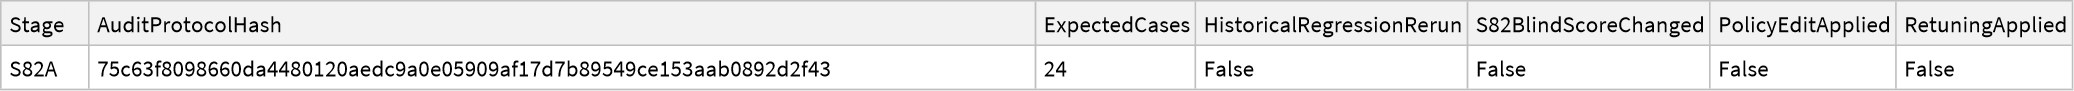

In [78]:
ClearAll[
WorldCase82A,
EncodeStatePair82A,
PrepareMechanismWorld82A,
SemanticConflictCount82A,
CaseSignatureConflictCount82A,
WorldSummary82A
];

auditDepths82A={31,63};
auditAnswers82A=Range[4];
auditWorlds82A={
"FactualContinue",
"GlobalStop",
"LocalStopHybrid"
};

WorldCase82A[
world_String,
depth_Integer,
answer_Integer
]:=Switch[
world,
"FactualContinue",
Case59[depth,answer,"Continue"],
"GlobalStop",
Case59[depth,answer,"Stop"],
"LocalStopHybrid",
ApplyEdgePatch81[
Case59[depth,answer,"Continue"],
LocalMediatorPatch82[depth,answer]
],
_,
$Failed
];

EncodeStatePair82A[pair_List]:=Module[
{encoded},
encoded=First@EncodeRows75[
{<|
"Grammar"->"S82AMechanismObservation",
"Depth"->0,
"Answer"->0,
"Target"->"Unlabeled",
"StatePairs"->{pair}
|>},
frozen75D["Params"],
frozen75D["K"]
];
First[encoded["Codes"]]
];

auditProtocol82A=<|
"Stage"->"S82A",
"Name"->"BlindCounterfactualFailureMechanismAudit",
"Depths"->auditDepths82A,
"Answers"->auditAnswers82A,
"Worlds"->auditWorlds82A,
"ExpectedCases"->24,
"Purpose"->
"RawRadiusAndNodeLevelEncoderPolicyAttribution",
"PriorS82ResultChanged"->False,
"S82UsedForRetuning"->False,
"PolicyEditApplied"->False,
"CandidateSearchRun"->False,
"NewModelSelected"->False
|>;

auditProtocolHash82A=Hash[
Normal[auditProtocol82A],
"SHA256",
"HexString"
];

modelHashBeforeAudit82A=Hash[
Normal[frozen75D],
"SHA256",
"HexString"
];
coreHashBeforeAudit82A=minimalKernelHash79A;
coreDefinitionTextHashBeforeAudit82A=
minimalKernelDefinitionTextHash82A;
canonicalizerHashBeforeAudit82A=
canonicalizerImplementationHash79B;
neutralTopologyHashBeforeAudit82A=
topologyImplementationHash80;
interventionHashBeforeAudit82A=
interventionImplementationHash82;
auditProtocolHashBefore82A=auditProtocolHash82A;

Dataset[{<|
"Stage"->"S82A",
"AuditProtocolHash"->auditProtocolHash82A,
"ExpectedCases"->24,
"HistoricalRegressionRerun"->False,
"S82BlindScoreChanged"->False,
"PolicyEditApplied"->False,
"RetuningApplied"->False
|>}]


Dataset[{<|World -> FactualContinue, Cases -> 8, ReferenceActions -> <|Continue -> 8|>, 
 
>     Predictions -> <|Continue -> 8|>, Correct -> 8, Codes -> {{3, 3}, {4, 3}}, 
 
>     PolicyCollisionCodes -> {{3, 3}, {4, 3}}, RowsWithAnyPolicyHit -> 8, 
 
>     RowsWithAllCodesPolicyTriggered -> 8, QueriedDecisionRejectPresent -> 8, 
 
>     QueriedDecisionPolicyHit -> 8, NonQueriedPolicyHit -> 0, 
 
>     QueriedBranchPolicyHit -> 8, OutsideQueriedBranchPolicyHit -> 0, 
 
>     ObservationCount -> 8, TerminatedNaturally -> 8, HitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 2.67244|>, 
 
>    <|World -> GlobalStop, Cases -> 8, ReferenceActions -> <|Stop -> 8|>, 
 
>     Predictions -> <|Stop -> 8|>, Correct -> 8, Codes -> {{4, 4}, {5, 4}}, 
 
>     PolicyCollisionCodes -> {}, RowsWithAnyPolicyHit -> 0, 
 
>     RowsWithAllCodesPolicyTriggered -> 0, QueriedDecisionRejectPresent -> 8, 
 
>     QueriedDecisionPolicyHit -> 0, NonQueriedPolicyHit -> 0, 
 
>     QueriedBranchPolicyHit -> 0, OutsideQueriedBranchPolicyHit -> 0, 
 
>     ObservationCount -> 8, TerminatedNaturally -> 8, HitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 2.61459|>, 
 
>    <|World -> LocalStopHybrid, Cases -> 8, ReferenceActions -> <|Stop -> 8|>, 
 
>     Predictions -> <|Continue -> 8|>, Correct -> 0, Codes -> {{2, 2}, {3, 2}}, 
 
>     PolicyCollisionCodes -> {{2, 2}, {3, 2}}, RowsWithAnyPolicyHit -> 8, 
 
>     RowsWithAllCodesPolicyTriggered -> 8, QueriedDecisionRejectPresent -> 8, 
 
>     QueriedDecisionPolicyHit -> 8, NonQueriedPolicyHit -> 8, 
 
>     QueriedBranchPolicyHit -> 8, OutsideQueriedBranchPolicyHit -> 0, 
 
>     ObservationCount -> 16, TerminatedNaturally -> 8, HitSafetyCap -> 0, 
 
>     TotalTraceSeconds -> 2.66667|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{World, Cases, ReferenceActions, Predictions, 
 
>      Correct, Codes, PolicyCollisionCodes, RowsWithAnyPolicyHit, 
 
>      RowsWithAllCodesPolicyTriggered, QueriedDecisionRejectPresent, 
 
>      QueriedDecisionPolicyHit, NonQueriedPolicyHit, QueriedBranchPolicyHit, 
 
>      OutsideQueriedBranchPolicyHit, ObservationCount, TerminatedNaturally, 
 
>      HitSafetyCap, TotalTraceSeconds}, 
 
>     {TypeSystem`Atom[String], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`Atom[Integer], 1], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[
 
>         Integer], 2], 2], TypeSystem`Vector[TypeSystem`Vector[TypeSystem`Atom[
 
>         Integer], 2], TypeSystem`AnyLength], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 3], <||>]
Dataset[{<|NodeRawPairCrossWorldLabelConflictCount -> 0, 
 
>     NodeRadius2CrossWorldLabelConflictCount -> 0, 
 
>     NodeRadius3CrossWorldLabelConflictCount -> 0, 
 
>     NodeEncodedCodeCrossWorldLabelConflictCount -> 0, 
 
>     QueriedRawPairSemanticConflictCount -> 0, 
 
>     QueriedEncodedCodeSemanticConflictCount -> 0, 
 
>     CaseRawPairSetSemanticConflictCount -> 0, 
 
>     CaseRadius2SetSemanticConflictCount -> 0, 
 
>     CaseRadius3SetSemanticConflictCount -> 0, 
 
>     CaseEncodedCodeSetSemanticConflictCount -> 0, 
 
>     LocalFactualRawPairOverlapCount -> 0, LocalGlobalStopRawPairOverlapCount -> 0, 
 
>     LocalStopPolicyCollisionCodes -> {{2, 2}, {3, 2}}, 
 
>     LocalStopQueriedRawOverlapWithFactualRows -> 0, 
 
>     LocalStopQueriedCodeOverlapWithFactualRows -> 0, 
 
>     LocalStopRowsPredictedContinue -> 8, LocalStopRowsAllCodesPolicyTriggered -> 8, 
 
>     LocalStopQueriedDecisionPolicyHit -> 8, LocalStopNonQueriedPolicyHit -> 8, 
 
>     LocalStopQueriedBranchPolicyHit -> 8, LocalStopOutsideQuer
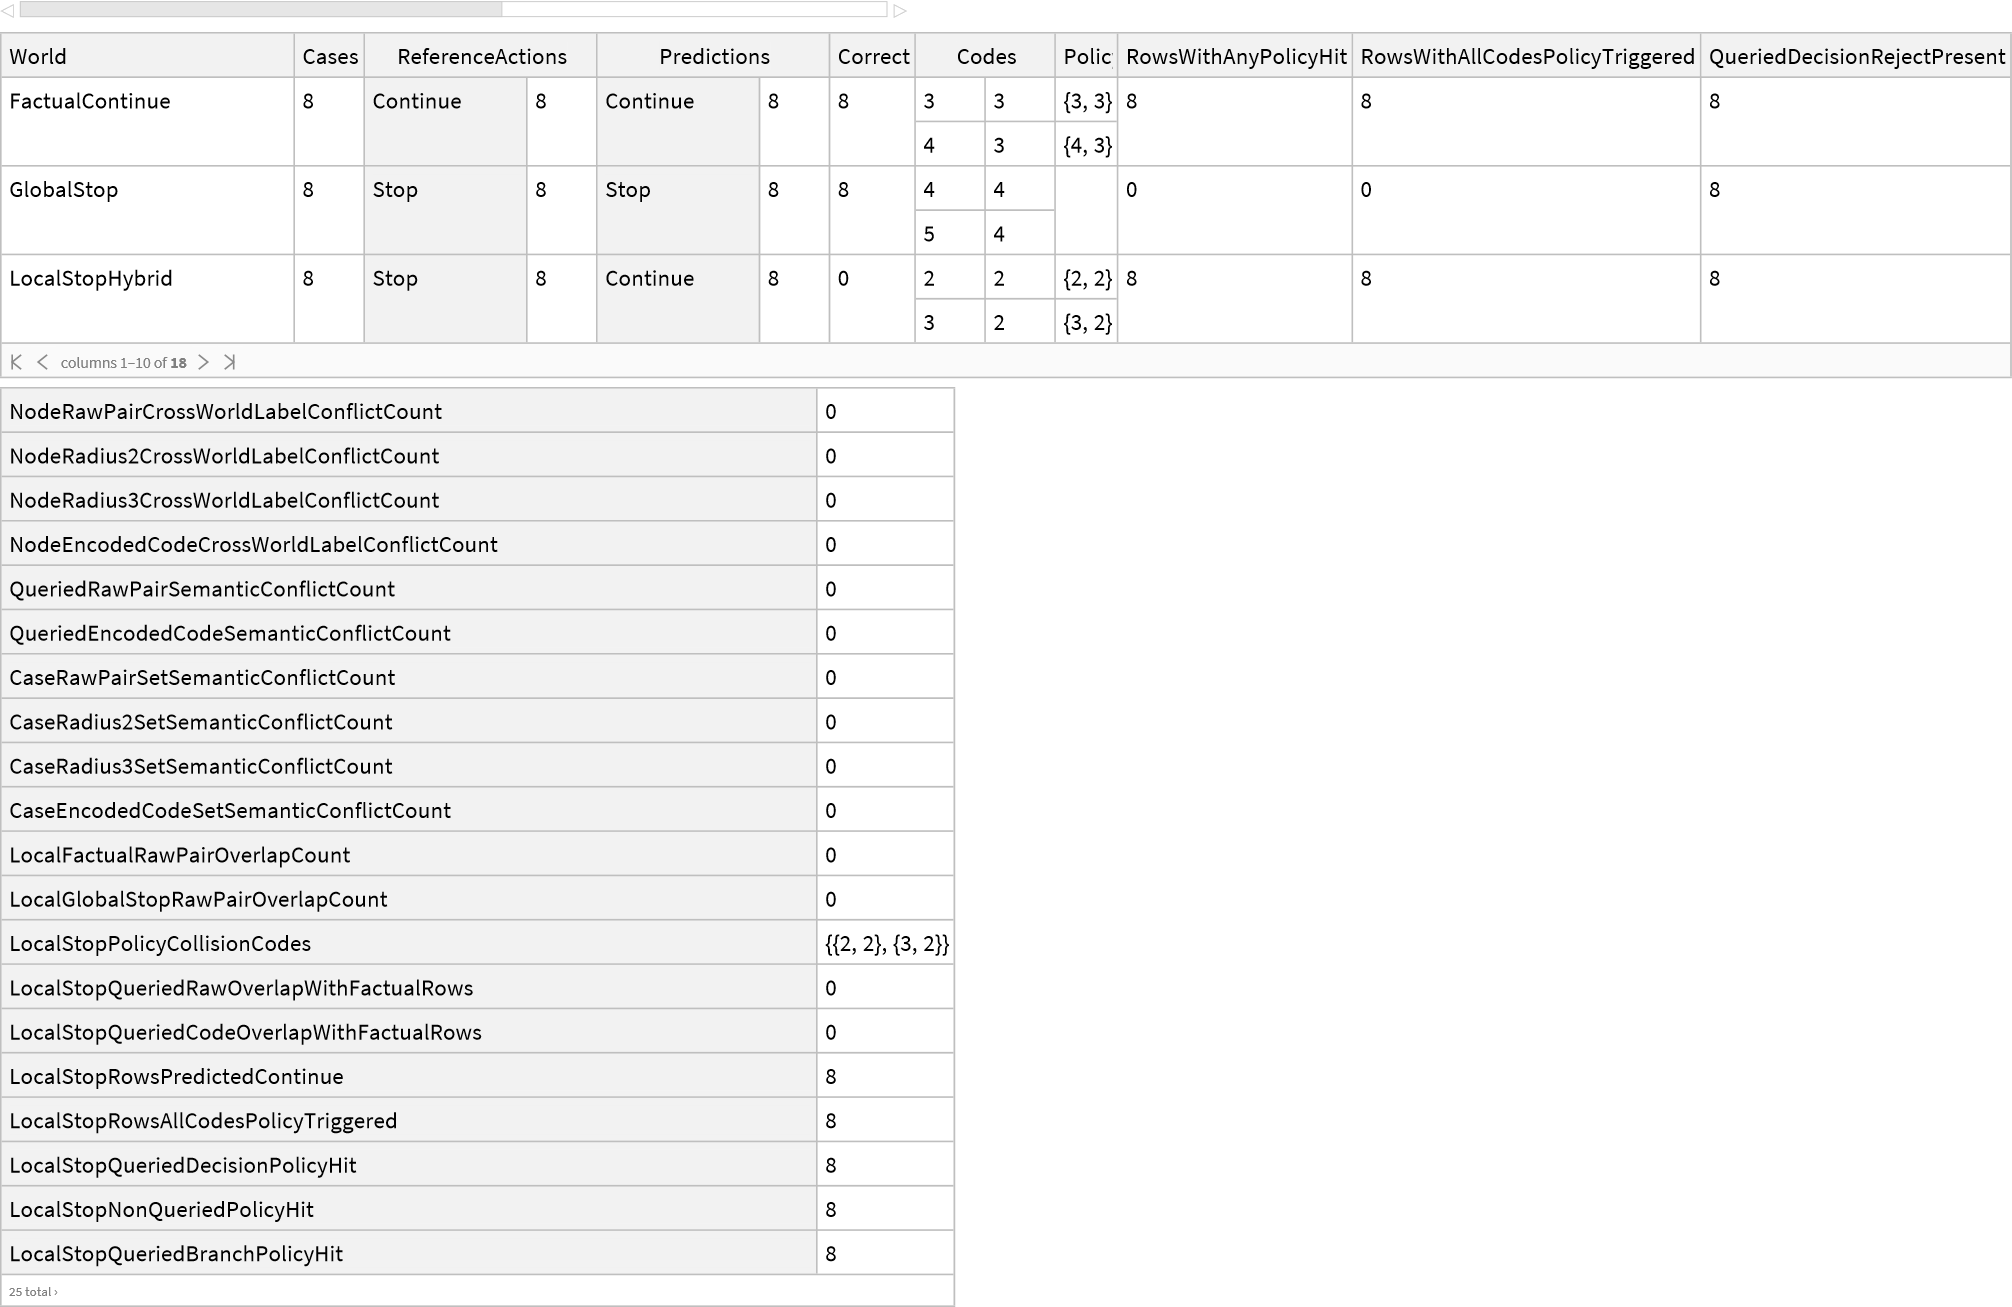

In [94]:
PrepareMechanismWorld82A[
world_String,
depth_Integer,
answer_Integer
]:=Module[
{
case,reference,canonicalization,canonicalCase,
traceSeconds,trace,levels,pack,vertexList,nodes,
queriedDecision,queriedSources,correct,wrong,dummy,
observations,codes,policyHits,prediction
},
case=WorldCase82A[world,depth,answer];
reference=ReferenceAction82[case];
canonicalization=CanonicalizePrivateDiamonds79B[case];
canonicalCase=canonicalization["Case"];
{traceSeconds,trace}=AbsoluteTiming[
RejectTrace78[canonicalCase]
];
levels=SigLevels61[canonicalCase,3];
pack=Pack60[canonicalCase];
vertexList=pack[[12]];
nodes=If[
Length[trace["Rejects"]]===0,
{},
DeleteDuplicates[trace["Rejects"][[All,2]]]
];
queriedDecision=canonicalCase[[1,6,answer]];
queriedSources={
queriedDecision,
queriedDecision+1,
queriedDecision+2
};
correct=canonicalCase[[1,5,answer]];
wrong=canonicalCase[[1,5,1+Mod[answer,4]]];
dummy=queriedDecision+3;
observations=Map[
Function[node,
Module[{pair,code,originalNode,role,queryBranchRelated},
pair={
Lookup[levels[[3]],node],
Lookup[levels[[4]],node]
};
code=EncodeStatePair82A[pair];
originalNode=vertexList[[node]];
role=Which[
SameQ[originalNode,queriedDecision],
"QueriedDecision",
MemberQ[queriedSources,originalNode],
"QueriedMediatorSource",
SameQ[originalNode,correct],
"QueriedCorrectDestination",
SameQ[originalNode,wrong],
"QueriedWrongDestination",
SameQ[originalNode,dummy],
"QueriedDummyDestination",
MemberQ[canonicalCase[[1,6]],originalNode],
"OtherDecision",
MemberQ[canonicalCase[[1,5]],originalNode],
"OtherAnswerDestination",
True,
"OtherReject"
];
queryBranchRelated=MemberQ[
Union[queriedSources,{correct,wrong,dummy}],
originalNode
];
<|
"World"->world,
"Depth"->depth,
"Answer"->answer,
"ReferenceAction"->reference,
"PackedNode"->node,
"OriginalNode"->originalNode,
"NodeRole"->role,
"QueryBranchRelated"->queryBranchRelated,
"RawPairHash"->Hash[pair,"SHA256","HexString"],
"Radius2Hash"->Hash[pair[[1]],"SHA256","HexString"],
"Radius3Hash"->Hash[pair[[2]],"SHA256","HexString"],
"Code"->code,
"CodeHash"->Hash[code,"SHA256","HexString"],
"PolicyHit"->MemberQ[frozen75D["Policy"],code]
|>
]
],
nodes
];
codes=DeleteDuplicates@Lookup[observations,"Code"];
policyHits=Intersection[codes,frozen75D["Policy"]];
prediction=If[
Length[policyHits]>0,
"Continue",
"Stop"
];
<|
"World"->world,
"Depth"->depth,
"Answer"->answer,
"ReferenceAction"->reference,
"TraceSeconds"->traceSeconds,
"TerminatedNaturally"->trace["TerminatedNaturally"],
"HitSafetyCap"->trace["HitSafetyCap"],
"RejectNodeCount"->Length[nodes],
"QueriedDecisionRejectPresent"->AnyTrue[
observations,
SameQ[#["NodeRole"],"QueriedDecision"]&
],
"Codes"->codes,
"PolicyHits"->policyHits,
"PolicyHitFraction"->If[
Length[codes]===0,
0.,
N[Length[policyHits]/Length[codes]]
],
"AllCodesPolicyTriggered"->And[
Length[codes]>0,
SameQ[Length[policyHits],Length[codes]]
],
"QueriedDecisionPolicyHit"->AnyTrue[
observations,
And[
SameQ[#["NodeRole"],"QueriedDecision"],
TrueQ[#["PolicyHit"]]
]&
],
"NonQueriedPolicyHit"->AnyTrue[
observations,
And[
!SameQ[#["NodeRole"],"QueriedDecision"],
TrueQ[#["PolicyHit"]]
]&
],
"QueriedBranchPolicyHit"->AnyTrue[
observations,
And[
TrueQ[#["QueryBranchRelated"]],
TrueQ[#["PolicyHit"]]
]&
],
"OutsideQueriedBranchPolicyHit"->AnyTrue[
observations,
And[
!TrueQ[#["QueryBranchRelated"]],
TrueQ[#["PolicyHit"]]
]&
],
"RawPairHashes"->DeleteDuplicates@Lookup[
observations,
"RawPairHash"
],
"Radius2Hashes"->DeleteDuplicates@Lookup[
observations,
"Radius2Hash"
],
"Radius3Hashes"->DeleteDuplicates@Lookup[
observations,
"Radius3Hash"
],
"CodeHashes"->DeleteDuplicates@Lookup[
observations,
"CodeHash"
],
"Prediction"->prediction,
"Correct"->SameQ[prediction,reference],
"Observations"->observations
|>
];

mechanismRows82A=Flatten[
Table[
PrepareMechanismWorld82A[world,depth,answer],
{world,auditWorlds82A},
{depth,auditDepths82A},
{answer,auditAnswers82A}
],
2
];

mechanismObservations82A=Flatten[
Lookup[mechanismRows82A,"Observations"],
1
];

SemanticConflictCount82A[
observations_List,
key_String
]:=Module[{groups},
groups=Values@GroupBy[
observations,
Lookup[#,key]&
];
Count[
groups,
group_/;Length[
DeleteDuplicates@Lookup[group,"ReferenceAction"]
]>1
]
];

CaseSignatureConflictCount82A[
rows_List,
key_String
]:=Module[{groups},
groups=Values@GroupBy[
rows,
Hash[Sort@Lookup[#,key],"SHA256","HexString"]&
];
Count[
groups,
group_/;Length[
DeleteDuplicates@Lookup[group,"ReferenceAction"]
]>1
]
];

WorldSummary82A[world_String]:=Module[
{rows,observations},
rows=Select[
mechanismRows82A,
SameQ[#["World"],world]&
];
observations=Flatten[Lookup[rows,"Observations"],1];
<|
"World"->world,
"Cases"->Length[rows],
"ReferenceActions"->Counts@Lookup[rows,"ReferenceAction"],
"Predictions"->Counts@Lookup[rows,"Prediction"],
"Correct"->Count[rows,row_/;TrueQ[row["Correct"]]],
"Codes"->Union@@Lookup[rows,"Codes"],
"PolicyCollisionCodes"->Intersection[
Union@@Lookup[rows,"Codes"],
frozen75D["Policy"]
],
"RowsWithAnyPolicyHit"->Count[
rows,
row_/;Length[row["PolicyHits"]]>0
],
"RowsWithAllCodesPolicyTriggered"->Count[
rows,
row_/;TrueQ[row["AllCodesPolicyTriggered"]]
],
"QueriedDecisionRejectPresent"->Count[
rows,
row_/;TrueQ[row["QueriedDecisionRejectPresent"]]
],
"QueriedDecisionPolicyHit"->Count[
rows,
row_/;TrueQ[row["QueriedDecisionPolicyHit"]]
],
"NonQueriedPolicyHit"->Count[
rows,
row_/;TrueQ[row["NonQueriedPolicyHit"]]
],
"QueriedBranchPolicyHit"->Count[
rows,
row_/;TrueQ[row["QueriedBranchPolicyHit"]]
],
"OutsideQueriedBranchPolicyHit"->Count[
rows,
row_/;TrueQ[row["OutsideQueriedBranchPolicyHit"]]
],
"ObservationCount"->Length[observations],
"TerminatedNaturally"->Count[
rows,
row_/;TrueQ[row["TerminatedNaturally"]]
],
"HitSafetyCap"->Count[
rows,
row_/;TrueQ[row["HitSafetyCap"]]
],
"TotalTraceSeconds"->Total@Lookup[rows,"TraceSeconds"]
|>
];

worldSummary82A=WorldSummary82A/@auditWorlds82A;

factualRows82A=Select[
mechanismRows82A,
SameQ[#["World"],"FactualContinue"]&
];
globalStopRows82A=Select[
mechanismRows82A,
SameQ[#["World"],"GlobalStop"]&
];
localStopRows82A=Select[
mechanismRows82A,
SameQ[#["World"],"LocalStopHybrid"]&
];

factualQueriedObservations82A=Select[
mechanismObservations82A,
And[
SameQ[#["World"],"FactualContinue"],
SameQ[#["NodeRole"],"QueriedDecision"]
]&
];
globalStopQueriedObservations82A=Select[
mechanismObservations82A,
And[
SameQ[#["World"],"GlobalStop"],
SameQ[#["NodeRole"],"QueriedDecision"]
]&
];
localStopQueriedObservations82A=Select[
mechanismObservations82A,
And[
SameQ[#["World"],"LocalStopHybrid"],
SameQ[#["NodeRole"],"QueriedDecision"]
]&
];

factualQueriedRawHashes82A=DeleteDuplicates@Lookup[
factualQueriedObservations82A,
"RawPairHash"
];
factualQueriedCodes82A=DeleteDuplicates@Lookup[
factualQueriedObservations82A,
"Code"
];

mechanismSummary82A=<|
"NodeRawPairCrossWorldLabelConflictCount"->
SemanticConflictCount82A[
mechanismObservations82A,
"RawPairHash"
],
"NodeRadius2CrossWorldLabelConflictCount"->
SemanticConflictCount82A[
mechanismObservations82A,
"Radius2Hash"
],
"NodeRadius3CrossWorldLabelConflictCount"->
SemanticConflictCount82A[
mechanismObservations82A,
"Radius3Hash"
],
"NodeEncodedCodeCrossWorldLabelConflictCount"->
SemanticConflictCount82A[
mechanismObservations82A,
"CodeHash"
],
"QueriedRawPairSemanticConflictCount"->
SemanticConflictCount82A[
Join[
factualQueriedObservations82A,
globalStopQueriedObservations82A,
localStopQueriedObservations82A
],
"RawPairHash"
],
"QueriedEncodedCodeSemanticConflictCount"->
SemanticConflictCount82A[
Join[
factualQueriedObservations82A,
globalStopQueriedObservations82A,
localStopQueriedObservations82A
],
"CodeHash"
],
"CaseRawPairSetSemanticConflictCount"->
CaseSignatureConflictCount82A[
mechanismRows82A,
"RawPairHashes"
],
"CaseRadius2SetSemanticConflictCount"->
CaseSignatureConflictCount82A[
mechanismRows82A,
"Radius2Hashes"
],
"CaseRadius3SetSemanticConflictCount"->
CaseSignatureConflictCount82A[
mechanismRows82A,
"Radius3Hashes"
],
"CaseEncodedCodeSetSemanticConflictCount"->
CaseSignatureConflictCount82A[
mechanismRows82A,
"CodeHashes"
],
"LocalFactualRawPairOverlapCount"->Length@Intersection[
Union@@Lookup[localStopRows82A,"RawPairHashes"],
Union@@Lookup[factualRows82A,"RawPairHashes"]
],
"LocalGlobalStopRawPairOverlapCount"->Length@Intersection[
Union@@Lookup[localStopRows82A,"RawPairHashes"],
Union@@Lookup[globalStopRows82A,"RawPairHashes"]
],
"LocalStopPolicyCollisionCodes"->Intersection[
Union@@Lookup[localStopRows82A,"Codes"],
frozen75D["Policy"]
],
"LocalStopQueriedRawOverlapWithFactualRows"->Count[
localStopQueriedObservations82A,
observation_/;MemberQ[
factualQueriedRawHashes82A,
observation["RawPairHash"]
]
],
"LocalStopQueriedCodeOverlapWithFactualRows"->Count[
localStopQueriedObservations82A,
observation_/;MemberQ[
factualQueriedCodes82A,
observation["Code"]
]
],
"LocalStopRowsPredictedContinue"->Count[
localStopRows82A,
row_/;SameQ[row["Prediction"],"Continue"]
],
"LocalStopRowsAllCodesPolicyTriggered"->Count[
localStopRows82A,
row_/;TrueQ[row["AllCodesPolicyTriggered"]]
],
"LocalStopQueriedDecisionPolicyHit"->Count[
localStopRows82A,
row_/;TrueQ[row["QueriedDecisionPolicyHit"]]
],
"LocalStopNonQueriedPolicyHit"->Count[
localStopRows82A,
row_/;TrueQ[row["NonQueriedPolicyHit"]]
],
"LocalStopQueriedBranchPolicyHit"->Count[
localStopRows82A,
row_/;TrueQ[row["QueriedBranchPolicyHit"]]
],
"LocalStopOutsideQueriedBranchPolicyHit"->Count[
localStopRows82A,
row_/;TrueQ[row["OutsideQueriedBranchPolicyHit"]]
],
"AllPolicyAggregationWouldContinueRows"->Count[
localStopRows82A,
row_/;TrueQ[row["AllCodesPolicyTriggered"]]
],
"QueryOnlyAggregationWouldContinueRows"->Count[
localStopRows82A,
row_/;TrueQ[row["QueriedDecisionPolicyHit"]]
],
"AnyToAllAggregationFixedRows"->Count[
localStopRows82A,
row_/;!TrueQ[row["AllCodesPolicyTriggered"]]
],
"AnyToQueryOnlyAggregationFixedRows"->Count[
localStopRows82A,
row_/;!TrueQ[row["QueriedDecisionPolicyHit"]]
]
|>;

Column[{
Dataset[worldSummary82A],
Dataset[{mechanismSummary82A}]
}]


Dataset[{<|Stage -> S82A, Name -> BlindCounterfactualFailureMechanismAudit, 
 
>     PriorS82BlindResultHash -> 
 
>      64be56fb8ef29638666efaf92cdcd03994a43e3328236fd0f7bd73a4808aa58f, 
 
>     S82FailureFingerprintReproduced -> True, CasesAudited -> 24, 
 
>     RuntimeMinimalKernelHash -> 
 
>      ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34, 
 
>     LegacyCheckpointMinimalKernelHash -> 
 
>      ec291466f20922dc4b2b879853cd3879c37151fb7e96c34eff45dcb185fe7f34, 
 
>     MinimalKernelDefinitionTextHash -> 
 
>      d56be85db649ba1ea4118050a019d35a07c28f394396858f1d40a1f90572b922, 
 
>     StableFrozenArchitectureHash -> 
 
>      d7d16575e25bd1090e35484931dedae9f80254475ee49cd2d79d43f5d4d1355d, 
 
>     NodeRawPairCrossWorldLabelConflictCount -> 0, 
 
>     QueriedRawPairSemanticConflictCount -> 0, 
 
>     QueriedEncodedCodeSemanticConflictCount -> 0, 
 
>     CaseRawPairSetSemanticConflictCount -> 0, 
 
>     CaseEncodedCodeSetSemanticConflictCount -> 0, 
 
>     LocalFactualRawPairOverlapCount -> 0, LocalGlobalStopRawPairOverlapCount -> 0, 
 
>     LocalStopPolicyCollisionCodes -> {{2, 2}, {3, 2}}, 
 
>     LocalStopQueriedRawOverlapWithFactualRows -> 0, 
 
>     LocalStopQueriedCodeOverlapWithFactualRows -> 0, 
 
>     LocalStopRowsPredictedContinue -> 8, LocalStopRowsAllCodesPolicyTriggered -> 8, 
 
>     LocalStopQueriedDecisionPolicyHit -> 8, LocalStopNonQueriedPolicyHit -> 8, 
 
>     LocalStopQueriedBranchPolicyHit -> 8, LocalStopOutsideQueriedBranchPolicyHit -> 0, 
 
>     AllPolicyAggregationWouldContinueRows -> 8, 
 
>     QueryOnlyAggregationWouldContinueRows -> 8, AnyToAllAggregationFixedRows -> 0, 
 
>     AnyToQueryOnlyAggregationFixedRows -> 0, ModelChanged -> False, 
 
>     CoreChanged -> False, CanonicalizerChanged -> False, 
 
>     NeutralTopologyChanged -> False, PolicyEditApplied -> False, 
 
>     RetuningApplied -> False, CandidateSearchRun -> False, 
 
>     AuditValidityPassed -> True, RootCause -> 
 
>      QUERY_LOCAL_FROZEN_POLICY_COLLISION_AFTER_ENCODING, AuditOnly -> True, 
 
>     S82BlindResultChanged -> False, 
 
>     AuditResultHash -> 
 
>      bcdcd4ce2882cc0f3ce8e605508e469271f2bdba482b7389795f77a1fb4b6919, 
 
>     SuggestedNextStage -> 
 
>      S82B_QUERY_ANCHORED_SEMANTIC_REPRESENTATION_DESIGN_NO_BLIND_RETUNING|>}, 
 
>   TypeSystem`Vector[TypeSystem`Assoc[TypeSystem`Atom[String], TypeSystem`AnyType, 42], 
 
>    1], <||>]
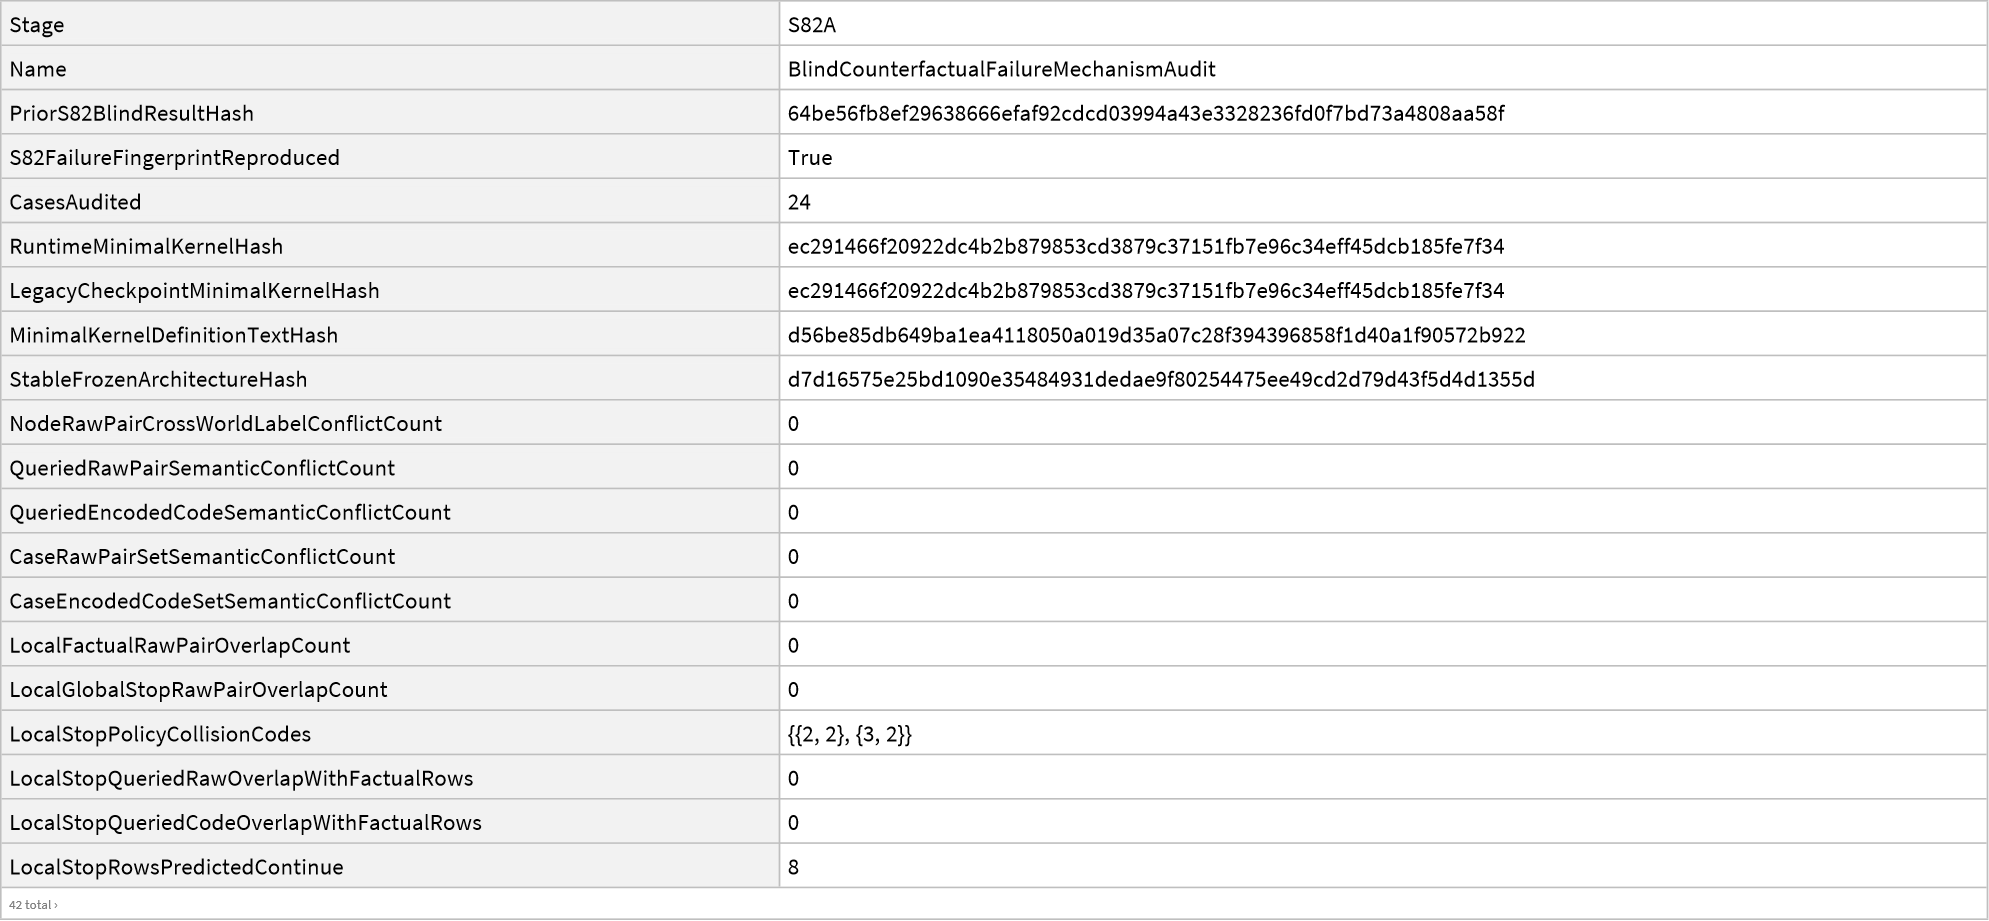

In [111]:
modelHashAfterAudit82A=Hash[
Normal[frozen75D],"SHA256","HexString"
];
coreHashAfterAudit82A=Hash[
{
DownValues[P59],DownValues[A59],DownValues[T59],DownValues[Case59],
OwnValues[rw60],DownValues[Pack60],DownValues[SigLevels61],
DownValues[PropagationSafetyCap78],DownValues[RejectTrace78],
DownValues[DecisionStatePairsFromRejects78],DownValues[EncodeRows75],
DownValues[DiamondIn72],DownValues[DoubleDiamondIn79],DownValues[Case79]
},"SHA256","HexString"
];
coreDefinitionTextHashAfterAudit82A=Hash[
ToString[InputForm[CoreDefinitionBundle82A[]]],
"SHA256",
"HexString"
];
canonicalizerHashAfterAudit82A=Hash[
{
DownValues[FindPrivateDiamond79B],
DownValues[CanonicalizePrivateDiamonds79B],
DownValues[CanonicalCase79B]
},"SHA256","HexString"
];
stableFrozenArchitectureHashAfterAudit82A=Hash[
{
Normal[frozen75D],
coreDefinitionTextHashAfterAudit82A,
canonicalizerHashAfterAudit82A
},
"SHA256",
"HexString"
];
neutralTopologyHashAfterAudit82A=Hash[
{
DownValues[HierarchicalDiamondIn80],
DownValues[Case80]
},"SHA256","HexString"
];
interventionHashAfterAudit82A=Hash[
{
DownValues[LocalMediatorSources82],
DownValues[FullSemanticPatch82],
DownValues[LocalMediatorPatch82],
DownValues[ReferenceAction82]
},"SHA256","HexString"
];
auditProtocolHashAfter82A=Hash[
Normal[auditProtocol82A],"SHA256","HexString"
];

integrityPassed82A=And[
SameQ[modelHashBeforeAudit82A,modelHashAfterAudit82A],
SameQ[modelHashAfterAudit82A,expectedFrozenModelHash79A],
SameQ[coreHashBeforeAudit82A,coreHashAfterAudit82A],
SameQ[
coreDefinitionTextHashBeforeAudit82A,
coreDefinitionTextHashAfterAudit82A
],
SameQ[
coreDefinitionTextHashAfterAudit82A,
expectedMinimalKernelDefinitionTextHash82A
],
SameQ[
canonicalizerHashBeforeAudit82A,
canonicalizerHashAfterAudit82A
],
SameQ[
canonicalizerHashAfterAudit82A,
expectedCanonicalizerHash82A
],
SameQ[
stableFrozenArchitectureHashAfterAudit82A,
expectedStableFrozenArchitectureHash82A
],
SameQ[
neutralTopologyHashBeforeAudit82A,
neutralTopologyHashAfterAudit82A
],
SameQ[
neutralTopologyHashAfterAudit82A,
expectedNeutralTopologyHash82A
],
SameQ[
interventionHashBeforeAudit82A,
interventionHashAfterAudit82A
],
SameQ[
interventionHashAfterAudit82A,
expectedInterventionHash82A
],
SameQ[
auditProtocolHashBefore82A,
auditProtocolHashAfter82A
]
];

auditValidityPassed82A=And[
TrueQ[preflightPassed82A],
TrueQ[integrityPassed82A],
SameQ[Length[mechanismRows82A],24],
SameQ[
Count[
mechanismRows82A,
row_/;TrueQ[row["TerminatedNaturally"]]
],
24
],
SameQ[
Count[
mechanismRows82A,
row_/;TrueQ[row["HitSafetyCap"]]
],
0
],
SameQ[Counts@Lookup[factualRows82A,"ReferenceAction"],<|"Continue"->8|>],
SameQ[Counts@Lookup[globalStopRows82A,"ReferenceAction"],<|"Stop"->8|>],
SameQ[Counts@Lookup[localStopRows82A,"ReferenceAction"],<|"Stop"->8|>]
];

s82FailureFingerprintReproduced82A=And[
SameQ[
Count[factualRows82A,row_/;TrueQ[row["Correct"]]],
8
],
SameQ[
mechanismSummary82A["LocalStopRowsPredictedContinue"],
8
],
SameQ[
Union@@Lookup[factualRows82A,"Codes"],
{{3,3},{4,3}}
],
SameQ[
Union@@Lookup[localStopRows82A,"Codes"],
{{2,2},{3,2}}
]
];

rootCause82A=Which[
!TrueQ[auditValidityPassed82A],
"INVALID_AUDIT",
!TrueQ[s82FailureFingerprintReproduced82A],
"S82_FAILURE_FINGERPRINT_NOT_REPRODUCED",
mechanismSummary82A[
"CaseRawPairSetSemanticConflictCount"
]>0,
"CASE_LEVEL_RAW_STATE_SET_ALIASING",
mechanismSummary82A[
"LocalStopQueriedRawOverlapWithFactualRows"
]===8&&
mechanismSummary82A[
"LocalStopQueriedDecisionPolicyHit"
]===8,
"QUERY_LOCAL_RAW_STATE_ALIASING",
mechanismSummary82A[
"LocalStopQueriedCodeOverlapWithFactualRows"
]===8&&
mechanismSummary82A[
"LocalStopQueriedDecisionPolicyHit"
]===8,
"QUERY_LOCAL_ENCODER_ALIASING",
mechanismSummary82A[
"LocalStopQueriedDecisionPolicyHit"
]===8,
"QUERY_LOCAL_FROZEN_POLICY_COLLISION_AFTER_ENCODING",
mechanismSummary82A[
"LocalStopQueriedBranchPolicyHit"
]>0,
"QUERY_BRANCH_FOOTPRINT_POLICY_COLLISION",
mechanismSummary82A[
"LocalStopOutsideQueriedBranchPolicyHit"
]>0,
"OFF_QUERY_REJECT_TOKEN_LEAK_THROUGH_ANYTRUE",
mechanismSummary82A["LocalStopRowsAllCodesPolicyTriggered"]===8,
"EXHAUSTIVE_FROZEN_POLICY_TOKEN_ALIASING",
True,
"UNRESOLVED_LOCAL_COUNTERFACTUAL_REPRESENTATION_FAILURE"
];

auditPayload82A=<|
"Stage"->"S82A",
"Name"->"BlindCounterfactualFailureMechanismAudit",
"PriorS82BlindResultHash"->expectedS82BlindResultHash82A,
"S82FailureFingerprintReproduced"->
s82FailureFingerprintReproduced82A,
"CasesAudited"->Length[mechanismRows82A],
"RuntimeMinimalKernelHash"->coreHashAfterAudit82A,
"LegacyCheckpointMinimalKernelHash"->
expectedMinimalKernelHash82A,
"MinimalKernelDefinitionTextHash"->
coreDefinitionTextHashAfterAudit82A,
"StableFrozenArchitectureHash"->
stableFrozenArchitectureHashAfterAudit82A,
"NodeRawPairCrossWorldLabelConflictCount"->
mechanismSummary82A[
"NodeRawPairCrossWorldLabelConflictCount"
],
"QueriedRawPairSemanticConflictCount"->
mechanismSummary82A[
"QueriedRawPairSemanticConflictCount"
],
"QueriedEncodedCodeSemanticConflictCount"->
mechanismSummary82A[
"QueriedEncodedCodeSemanticConflictCount"
],
"CaseRawPairSetSemanticConflictCount"->
mechanismSummary82A[
"CaseRawPairSetSemanticConflictCount"
],
"CaseEncodedCodeSetSemanticConflictCount"->
mechanismSummary82A[
"CaseEncodedCodeSetSemanticConflictCount"
],
"LocalFactualRawPairOverlapCount"->
mechanismSummary82A["LocalFactualRawPairOverlapCount"],
"LocalGlobalStopRawPairOverlapCount"->
mechanismSummary82A["LocalGlobalStopRawPairOverlapCount"],
"LocalStopPolicyCollisionCodes"->
mechanismSummary82A["LocalStopPolicyCollisionCodes"],
"LocalStopQueriedRawOverlapWithFactualRows"->
mechanismSummary82A[
"LocalStopQueriedRawOverlapWithFactualRows"
],
"LocalStopQueriedCodeOverlapWithFactualRows"->
mechanismSummary82A[
"LocalStopQueriedCodeOverlapWithFactualRows"
],
"LocalStopRowsPredictedContinue"->
mechanismSummary82A["LocalStopRowsPredictedContinue"],
"LocalStopRowsAllCodesPolicyTriggered"->
mechanismSummary82A["LocalStopRowsAllCodesPolicyTriggered"],
"LocalStopQueriedDecisionPolicyHit"->
mechanismSummary82A["LocalStopQueriedDecisionPolicyHit"],
"LocalStopNonQueriedPolicyHit"->
mechanismSummary82A["LocalStopNonQueriedPolicyHit"],
"LocalStopQueriedBranchPolicyHit"->
mechanismSummary82A[
"LocalStopQueriedBranchPolicyHit"
],
"LocalStopOutsideQueriedBranchPolicyHit"->
mechanismSummary82A[
"LocalStopOutsideQueriedBranchPolicyHit"
],
"AllPolicyAggregationWouldContinueRows"->
mechanismSummary82A[
"AllPolicyAggregationWouldContinueRows"
],
"QueryOnlyAggregationWouldContinueRows"->
mechanismSummary82A[
"QueryOnlyAggregationWouldContinueRows"
],
"AnyToAllAggregationFixedRows"->
mechanismSummary82A["AnyToAllAggregationFixedRows"],
"AnyToQueryOnlyAggregationFixedRows"->
mechanismSummary82A[
"AnyToQueryOnlyAggregationFixedRows"
],
"ModelChanged"->!SameQ[
modelHashBeforeAudit82A,
modelHashAfterAudit82A
],
"CoreChanged"->!SameQ[
coreHashBeforeAudit82A,
coreHashAfterAudit82A
],
"CanonicalizerChanged"->!SameQ[
canonicalizerHashBeforeAudit82A,
canonicalizerHashAfterAudit82A
],
"NeutralTopologyChanged"->!SameQ[
neutralTopologyHashBeforeAudit82A,
neutralTopologyHashAfterAudit82A
],
"PolicyEditApplied"->False,
"RetuningApplied"->False,
"CandidateSearchRun"->False,
"AuditValidityPassed"->auditValidityPassed82A,
"RootCause"->rootCause82A
|>;

auditResultHash82A=Hash[
Normal[auditPayload82A],"SHA256","HexString"
];

cert82A=Join[
auditPayload82A,
<|
"AuditOnly"->True,
"S82BlindResultChanged"->False,
"AuditResultHash"->auditResultHash82A,
"SuggestedNextStage"->If[
TrueQ[auditValidityPassed82A],
"S82B_QUERY_ANCHORED_SEMANTIC_REPRESENTATION_DESIGN_NO_BLIND_RETUNING",
"REPAIR_S82A_AUDIT_WITHOUT_CHANGING_FROZEN_MODEL"
]
|>
];

Dataset[{cert82A}]
